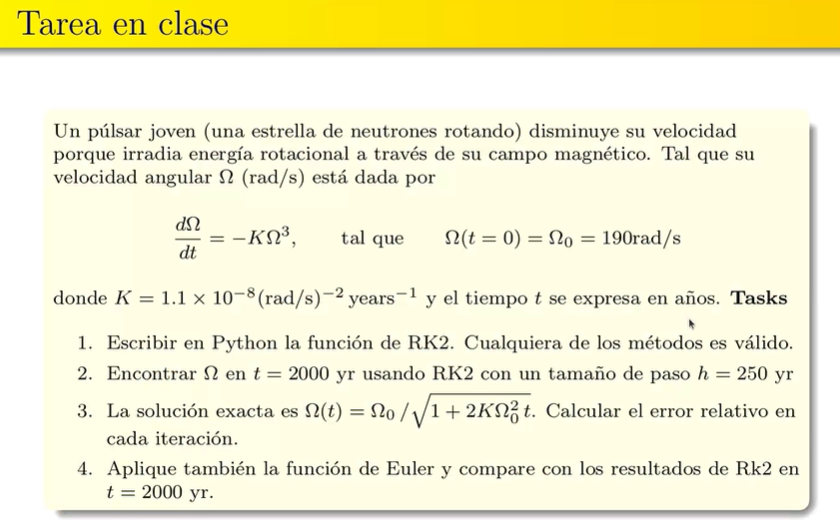

In [2]:
import numpy as np


K = 1.1e-8
Omega_0 = 190.0
h = 250.0
t_final = 2000.0

pasos = int(t_final / h)

# ALMACENAR LOS RESULTADOS
t_vals = np.zeros(pasos + 1)
Omega_rk2 = np.zeros(pasos + 1)
Omega_euler = np.zeros(pasos + 1)
Omega_exacto = np.zeros(pasos + 1)

error_rk2 = np.zeros(pasos + 1)
error_euler = np.zeros(pasos + 1)


# CONDICIONES INICIALES (PARA i = 0)
t_vals[0] = 0.0
Omega_rk2[0] = Omega_0
Omega_euler[0] = Omega_0

Omega_exacto[0] = Omega_0 / np.sqrt(1.0 + 2.0 * K * (Omega_0**2) * t_vals[0])
error_rk2[0] = np.abs((Omega_exacto[0] - Omega_rk2[0]) / Omega_exacto[0]) * 100.0
error_euler[0] = np.abs((Omega_exacto[0] - Omega_euler[0]) / Omega_exacto[0]) * 100.0


# BUCLE DE INTEGRACIÓN (EULER Y RK2 HEUN)
i = 0

while i < pasos:
    
    t_i = t_vals[i]
    
    # 1. METODO DE EULER
    f_euler = -K * (Omega_euler[i]**3)
    Omega_euler[i + 1] = Omega_euler[i] + f_euler * h
    
    # 2. METODO DE RK2 (HEUN)
    k1 = -K * (Omega_rk2[i]**3)
    Omega_predict = Omega_rk2[i] + k1 * h
    k2 = -K * (Omega_predict**3)
    
    Omega_rk2[i + 1] = Omega_rk2[i] + (0.5 * k1 + 0.5 * k2) * h
    
    # Avanzar tiempo
    t_vals[i + 1] = t_i + h
    
    # 3. SOLUCION Y ERRORES 
    Omega_exacto[i + 1] = Omega_0 / np.sqrt(1.0 + 2.0 * K * (Omega_0**2) * t_vals[i + 1])
    
    error_rk2[i + 1] = np.abs((Omega_exacto[i + 1] - Omega_rk2[i + 1]) / Omega_exacto[i + 1]) * 100.0
    error_euler[i + 1] = np.abs((Omega_exacto[i + 1] - Omega_euler[i + 1]) / Omega_exacto[i + 1]) * 100.0
    
    i = i + 1



# RESULTADOS 


print("TIEMPO FINAL")
print(t_vals[pasos])

print("\nOMEGA RK2 HEUN")
print(Omega_rk2[pasos])

print("\nERROR RELATIVO RK2")
print(error_rk2[pasos])

print("\nOMEGA EULER")
print(Omega_euler[pasos])

print("\nERROR RELATIVO EULER")
print(error_euler[pasos])

print("\nOMEGA EXACTO")
print(Omega_exacto[pasos])

TIEMPO FINAL
2000.0

OMEGA RK2 HEUN
118.24349328046189

ERROR RELATIVO RK2
0.12426621512962575

OMEGA EULER
114.61303250481375

ERROR RELATIVO EULER
2.9498752120219

OMEGA EXACTO
118.09673893279859
